House pricing EDA (Exploratory Data Analysis)

In [43]:
# Import essential library
import math
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
from IPython.display import display
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10,6]

In [44]:
#GLOBAL
DP = './Housing.csv'


Inference: The Datset has 1 numerical & 11 categorical features.


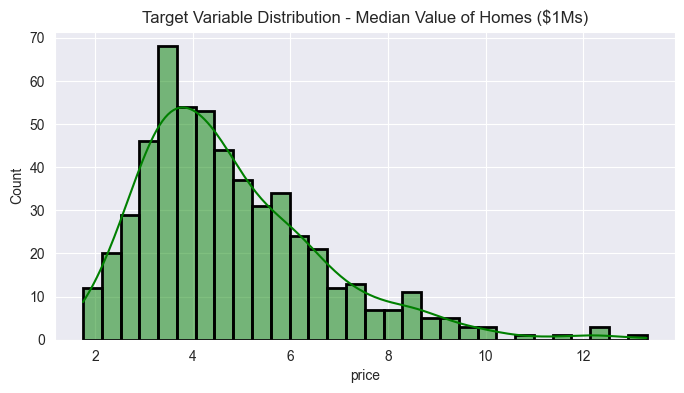

In [45]:
df = pd.read_csv(DP)
target = 'price'
features = [i for i in df.columns if i not in [target]]
nu = df[features].nunique().sort_values()
nf = []; cf = []; nnf = 0; ncf = 0; #numerical & categorical features

for i in range(df[features].shape[1]):
    if nu.values[i]<=16:cf.append(nu.index[i])
    else: nf.append(nu.index[i])

print('\n\033[1mInference:\033[0m The Datset has {} numerical & {} categorical features.'.format(len(nf),len(cf)))


plt.figure(figsize=(8,4))

sns.histplot(df[target]/1000000, color='g', edgecolor="black", linewidth=2, bins=30, kde=True)
plt.title('Target Variable Distribution - Median Value of Homes ($1Ms)')

plt.show()

Giá nhà nhìn chung tuân theo phân phối chuẩn

                               Visualising Categorical Features:                                


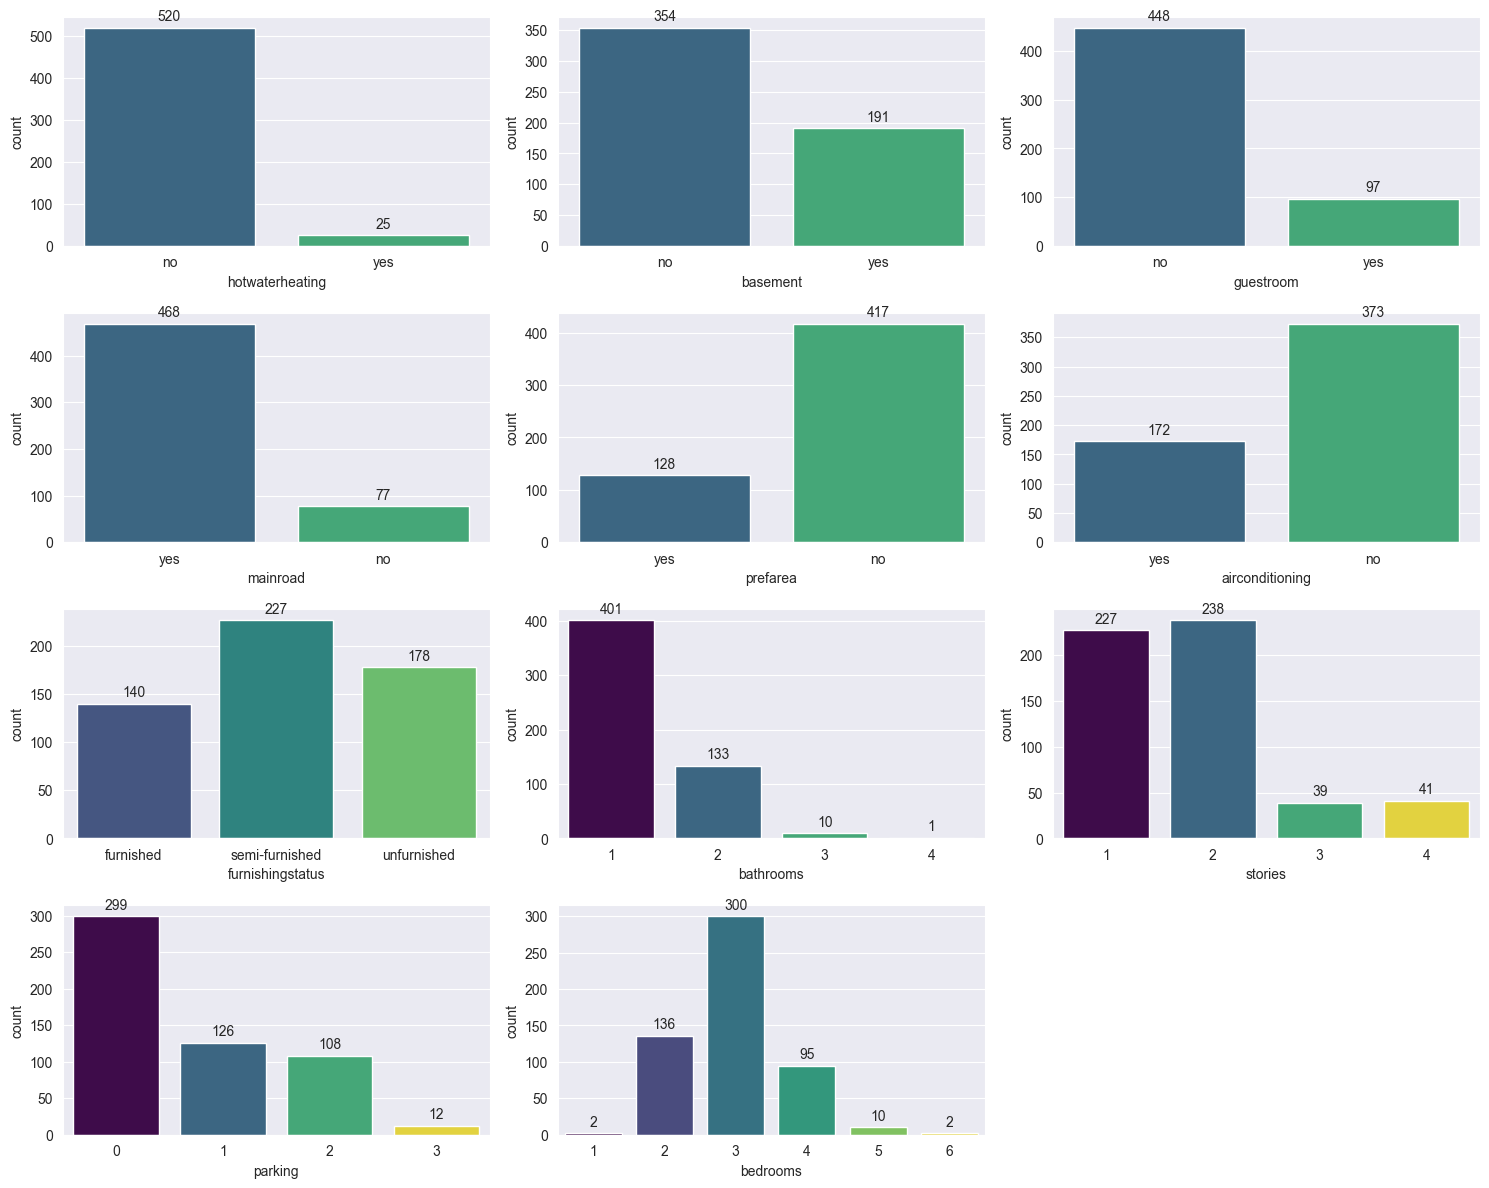

In [46]:
#Visualize các biến categorical
print('\033[1mVisualising Categorical Features:'.center(100))

n = 3
plt.figure(figsize=[15, 3 * math.ceil(len(cf)/n)])

for i in range(len(cf)):
    plt.subplot(math.ceil(len(cf)/n), n, i+1)
    #'viridis', 'pastel', 'muted', 'husl'
    ax = sns.countplot(x=df[cf[i]], hue=df[cf[i]], palette='viridis', legend=False)

    for container in ax.containers:
        ax.bar_label(container, padding=3)


plt.tight_layout()
plt.show()

                                                Numeric Features Distribution                                                 


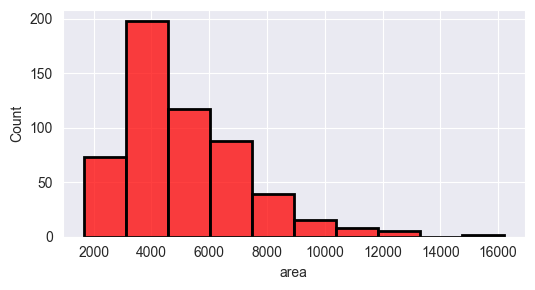

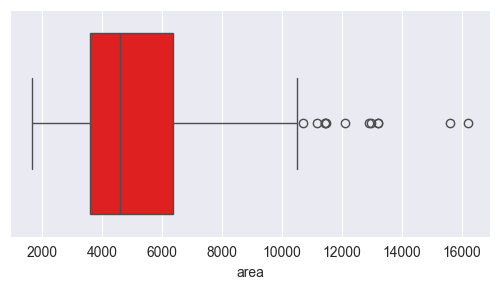

In [51]:
print('\033[1mNumeric Features Distribution'.center(130))
n = 3
clr = ['r', 'g', 'b', 'g', 'b', 'r']

plt.figure(figsize=[15, 3 * math.ceil(len(nf)/n)])
for i in range(len(nf)):
    plt.subplot(math.ceil(len(nf)/n), n, i+1)

    sns.histplot(
        x=df[nf[i]],
        edgecolor="black",
        linewidth=2,
        bins=10,
        color=clr[i % len(clr)]
    )
plt.tight_layout()
plt.show()

plt.figure(figsize=[15, 3 * math.ceil(len(nf)/n)])
for i in range(len(nf)):
    plt.subplot(math.ceil(len(nf)/n), n, i+1)

    sns.boxplot(
        x=df[nf[i]],
        color=clr[i % len(clr)]
    )
plt.tight_layout()
plt.show()

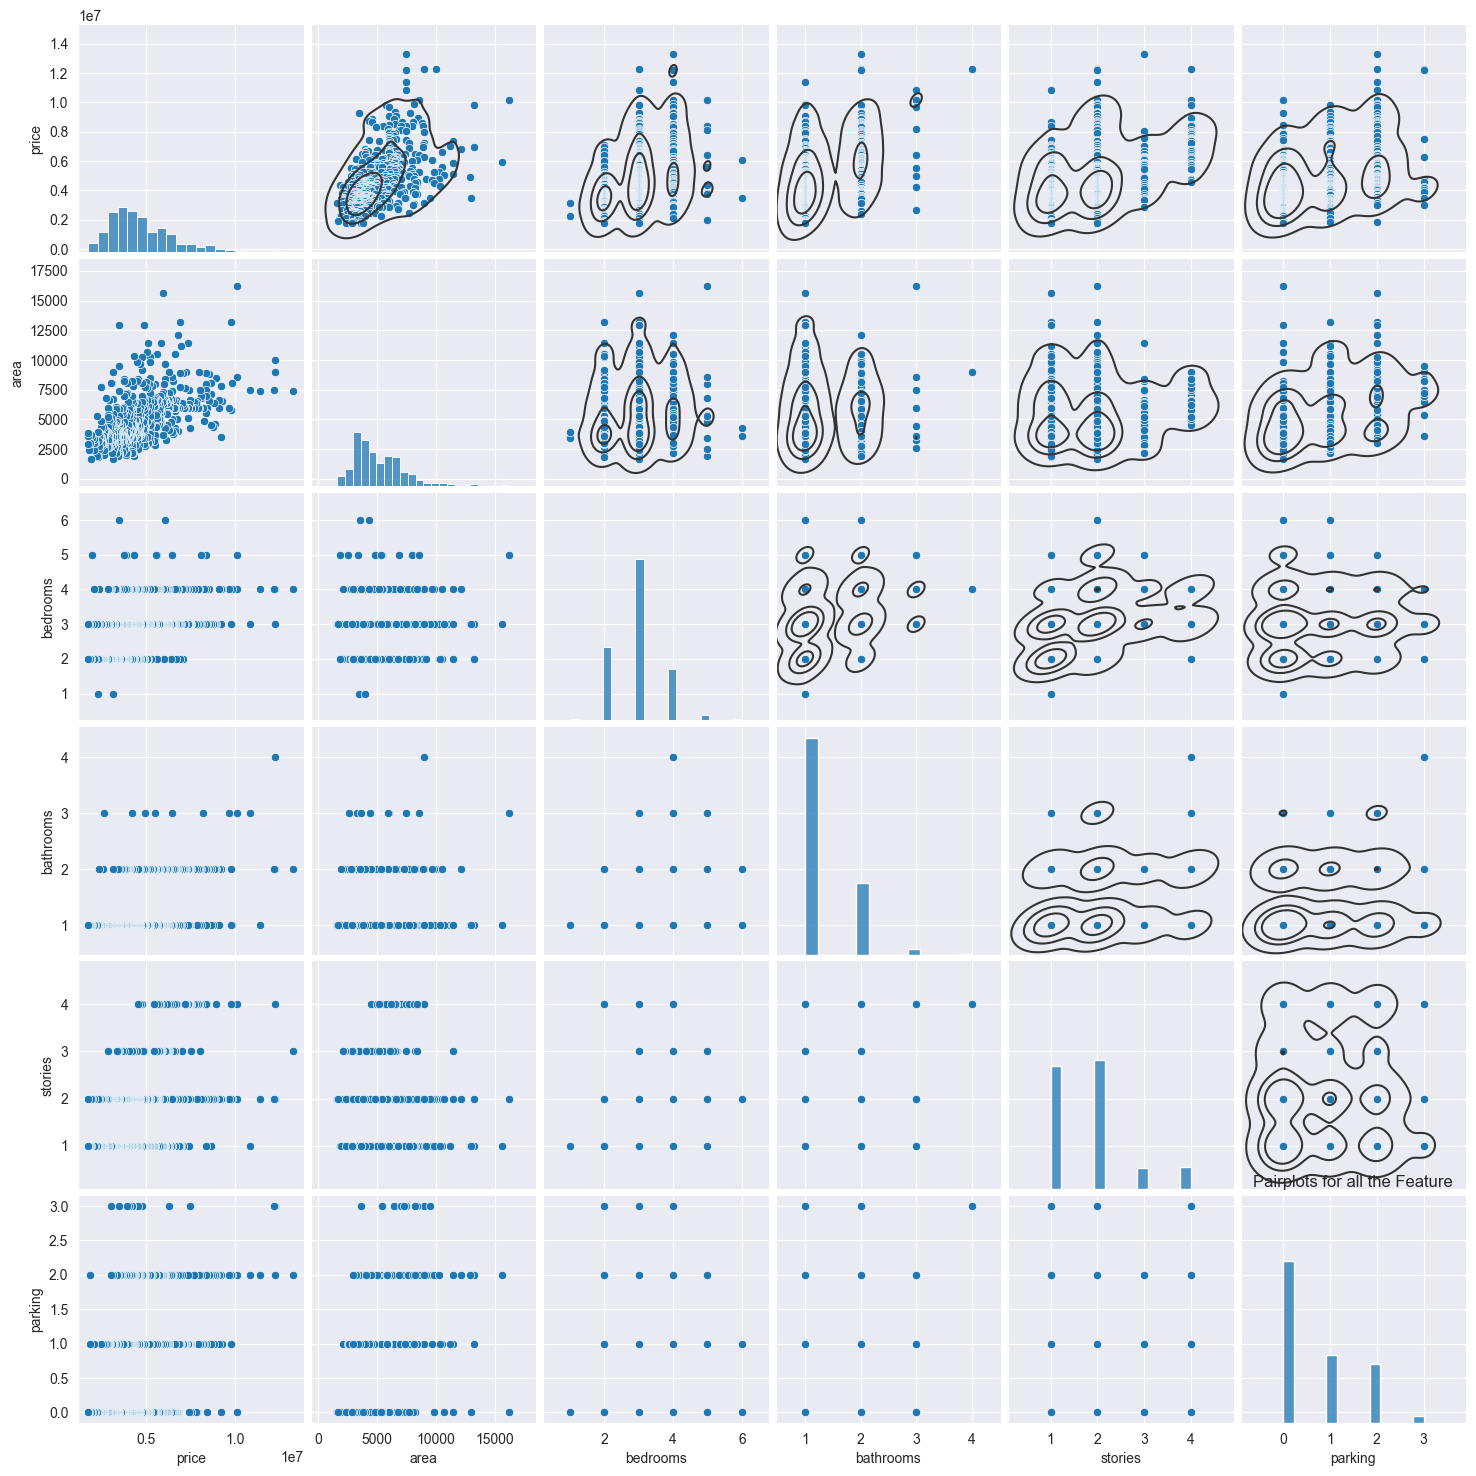

In [52]:
`#Quan hệ giữa tất cả các biến
g = sns.pairplot(df)
plt.title('Pairplots for all the Feature')
g.map_upper(sns.kdeplot, levels=4, color=".2")
plt.show()

Chúng ta có thể nhận thấy rằng một số đặc trưng có mối quan hệ tuyến tính với nhau. Tiếp theo, hãy phân tích sâu hơn để phát hiện hiện tượng đa cộng tuyến.